<div class="alert alert-block alert-info">
    <h3><b>Análisis de ventas</b></h3>
    <p>Proyecto de portafolio</p>
</div>

<div class="alert alert-block alert-info">
    <h3><b>1. Configuración inicial</b></h3>
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<div class="alert alert-block alert-info">
    <h3><b>2. Carga y exploración</b></h3>
</div>

In [16]:
# Cargamos el dataset
ventas_df = pd.read_csv('ventas_sucias.csv', sep=',', encoding='utf-8')

In [3]:
# Mostramos información general del dataset
ventas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_venta    21 non-null     object 
 1   fecha       21 non-null     object 
 2   producto    18 non-null     object 
 3   categoria   21 non-null     object 
 4   ventas      21 non-null     float64
 5   beneficio   20 non-null     float64
 6   descuento   20 non-null     float64
 7   Unnamed: 7  1 non-null      float64
dtypes: float64(4), object(4)
memory usage: 1.4+ KB


In [4]:
# Mostramos el dataño de filas y columnas
print(f"Filas: {ventas_df.shape[0]}, Columnas: {ventas_df.shape[1]}")

Filas: 21, Columnas: 8


In [15]:
# Verificamos columnas con valores nulos
ventas_df.isnull().sum()

id_venta     0
fecha        0
producto     0
categoria    0
ventas       0
beneficio    0
descuento    0
dtype: int64

In [17]:
# Transformamos la columnas a su tipo de datos
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')
ventas_df['id_venta'] = pd.to_numeric(ventas_df['id_venta'], errors='coerce')
ventas_df['ventas'] = pd.to_numeric(ventas_df['ventas'], errors='coerce')
ventas_df['beneficio'] = pd.to_numeric(ventas_df['beneficio'], errors='coerce')
ventas_df['descuento'] = pd.to_numeric(ventas_df['descuento'], errors='coerce')

/var/folders/59/2l2h0xwx2qqdy_162v0p4lpc0000gn/T/ipykernel_46821/268379564.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'], errors='coerce')


In [18]:
print("=== Valores negativos ===")
print(f"Ventas negativas: {len(ventas_df[ventas_df['ventas'] < 0])}")
print(f"Beneficio negativo: {len(ventas_df[ventas_df['beneficio'] < 0])}")
print(f"Descuento negativo: {len(ventas_df[ventas_df['descuento'] < 0])}")
print("\n=== Valores nulos ===")
print(ventas_df[['ventas', 'beneficio', 'descuento']].isnull().sum())
print("\n=== Filas con beneficio negativo ===")
print(ventas_df[ventas_df['beneficio'] < 0][['id_venta','descuento']])

=== Valores negativos ===
Ventas negativas: 0
Beneficio negativo: 5
Descuento negativo: 1

=== Valores nulos ===
ventas       0
beneficio    1
descuento    1
dtype: int64

=== Filas con beneficio negativo ===
    id_venta  descuento
3      104.0       0.00
6      107.0       0.25
13     114.0       0.30
14     115.0       0.40
17     118.0       0.20


<div class="alert alert-block alert-info">
    <h3><b>3. Limpieza</b></h3>
</div>


In [19]:
# Eliminamos la columna 'Unnamed: 7'
ventas_df = ventas_df.drop(columns=['Unnamed: 7'])

<p>
¿Porque eliminar está columna?
<br>
Se dicio borrar está columna, porque solo contaba con un valor, posiblemente esté desfasado a la hora de guardar y no tiene valor, ya que su fila cumple con todos los datos necesarios

In [20]:
# Cambiamos los valores nulos de 'producto' y 'categoria' por 'Desconocido'
ventas_df['producto'] = ventas_df['producto'].fillna('Desconocido')
ventas_df['categoria'] = ventas_df['categoria'].fillna('Desconocida')

In [21]:
# Corregir última fila (valores desplazados)
ventas_df.loc[20, 'fecha'] = '2024-03-15'
ventas_df.loc[20, 'id_venta'] = max(ventas_df['id_venta']) + 1
ventas_df.loc[20, 'ventas'] = 15.00
ventas_df.loc[20, 'beneficio'] = 2.00
ventas_df.loc[20, 'descuento'] = 0.20
ventas_df.loc[20, 'producto'] = 'Desconocido'
ventas_df.loc[20, 'categoria'] = 'Desconocida'

In [22]:
print("=== Verificación ===")
print(f"Shape final: {ventas_df.shape}")
print(f"\nTipos de datos:")
print(ventas_df.dtypes)
print(f"\nNulos en columnas clave:")
print(ventas_df[['producto', 'categoria', 'ventas', 'beneficio', 'descuento']].isnull().sum())
print(f"\nRango de fechas: {ventas_df['fecha'].min()} a {ventas_df['fecha'].max()}")
print(f"\nMuestras de filas corregidas:")
ventas_df.loc[[9, 20]]

=== Verificación ===
Shape final: (21, 7)

Tipos de datos:
id_venta            float64
fecha        datetime64[ns]
producto             object
categoria            object
ventas              float64
beneficio           float64
descuento           float64
dtype: object

Nulos en columnas clave:
producto     0
categoria    0
ventas       0
beneficio    0
descuento    0
dtype: int64

Rango de fechas: 2024-01-03 00:00:00 a 2024-12-03 00:00:00

Muestras de filas corregidas:


,id_venta,fecha,producto,categoria,ventas,beneficio,descuento
9,110.0,2024-06-03,Desconocido,Electronica,100.0,200.0,-50.0
20,121.0,2024-03-15,Desconocido,Desconocida,15.0,2.0,0.2


<div class="alert alert-block alert-info">
    <h3><b>4. Análisis de negocio</b></h3>
</div>

In [23]:
# Creamos margen
ventas_df['margen'] = ventas_df['beneficio'] / ventas_df['ventas']

# Creamos rangos de descuento
ventas_df['rango_descuento'] = pd.cut(ventas_df['descuento'], 
                                      bins=[-0.1, 0, 0.1, 0.2, 0.3, 1.0], 
                                      labels=['0%', '1-10%', '11-20%', '21-30%', '>30%'])

# Calcular métricas por rango
resumen_descuentos = ventas_df.groupby('rango_descuento', observed=True).agg(
    ventas_totales=('ventas', 'sum'),
    beneficio_total=('beneficio', 'sum'),
    margen_promedio=('margen', 'mean'),
    num_transacciones=('id_venta', 'count')
).round(2)

print("=== Resumen ===")
resumen_descuentos

=== Resumen ===


,ventas_totales,beneficio_total,margen_promedio,num_transacciones
rango_descuento,,,,
0%,270.5,53.2,0.16,10
1-10%,2550.0,510.0,0.20,4
11-20%,250.0,-21.0,0.02,3
21-30%,262.0,-12.0,-0.10,2
>30%,20.0,-5.0,-0.25,1


In [ ]:
# Productos problemáticos
# Productos que pierden dinero CON descuento
perdidas_con_descuento = ventas_df[(ventas_df['beneficio'] < 0) & (ventas_df['descuento'] > 0)]

# Productos que pierden dinero SIN descuento (problema de precio base)
perdidas_sin_descuento = ventas_df[(ventas_df['beneficio'] < 0) & (ventas_df['descuento'] == 0)]

print("\n=== PRODUCTOS CON PÉRDIDA ===")
print(f"Con descuento: {len(perdidas_con_descuento)} productos")
print(perdidas_con_descuento[['producto', 'categoria', 'ventas', 'beneficio', 'descuento']])
print(f"\nSin descuento: {len(perdidas_sin_descuento)} productos")
perdidas_sin_descuento[['producto', 'categoria', 'ventas', 'beneficio']]


=== PRODUCTOS CON PÉRDIDA ===
Con descuento: 4 productos
       producto    categoria  ventas  beneficio  descuento
6       Monitor  Electronica   250.0      -10.0       0.25
13   Archivador      Oficina    12.0       -2.0       0.30
14  Calculadora  Electronica    20.0       -5.0       0.40
17         Mesa      Oficina   150.0      -40.0       0.20

Sin descuento: 1 productos


,producto,categoria,ventas,beneficio
3,Desconocido,Papeleria,2.0,-0.5


In [25]:
# Rentabilidad por categoría
rentabilidad_categoria = ventas_df.groupby('categoria').agg(
    ventas_totales=('ventas', 'sum'),
    beneficio_total=('beneficio', 'sum'),
    margen_promedio=('margen', 'mean'),
    productos_vendidos=('producto', 'count')
).round(2).sort_values('margen_promedio', ascending=False)

print("\n=== Rentabilidad ===")
rentabilidad_categoria


=== Rentabilidad ===


,ventas_totales,beneficio_total,margen_promedio,productos_vendidos
categoria,,,,
Electronica,2866.0,684.2,0.32,9
Desconocida,15.0,2.0,0.13,1
Papeleria,9.5,1.0,0.09,4
Oficina,562.0,38.0,0.08,7


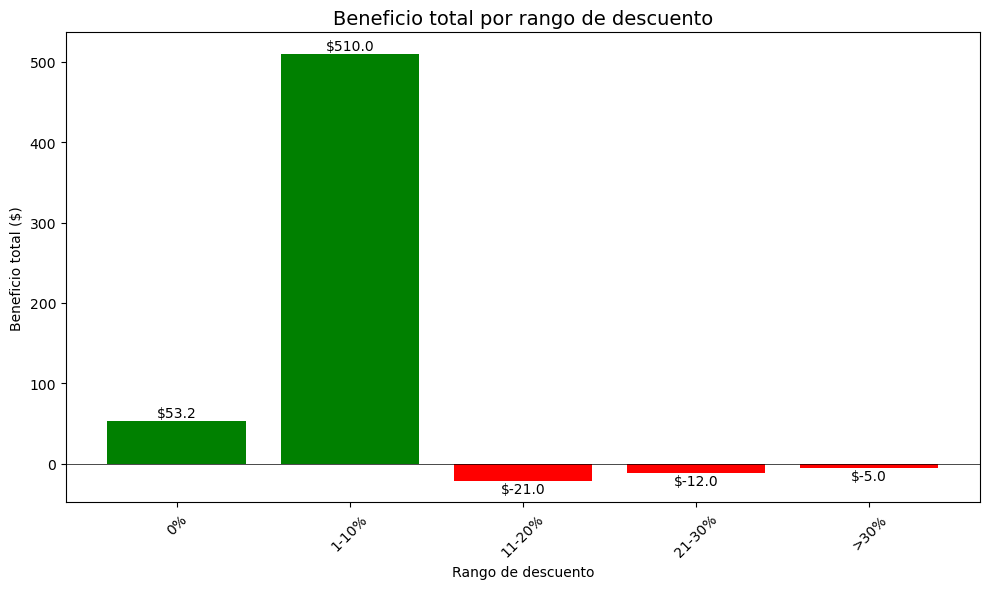

In [32]:
# Gráfico de barras: beneficio por rango de descuento
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in resumen_descuentos['beneficio_total']]
plt.bar(resumen_descuentos.index, resumen_descuentos['beneficio_total'], color=colors)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Beneficio total por rango de descuento', fontsize=14)
plt.xlabel('Rango de descuento')
plt.ylabel('Beneficio total ($)')
plt.xticks(rotation=45)
for i, v in enumerate(resumen_descuentos['beneficio_total']):
    plt.text(i, v + (5 if v > 0 else -15), f'${v}', ha='center')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
    <h3><b>5. Observaciones y recomendaciones</b></h3>
</div>

<p>Los descuentos superiores a 20% generan márgenes negativos</p>
<ul>
    <li>Acción 1: Eliminar descuentos mayores al 30% inmediatamente</li>
    <li>Acción 2: Reducir descuentos del 21 al 30% a un máximo del 15% en electrónica</li>
    <li>Acción 3: Revisar precios de Mesa y Calculadora, ya que tienen perdidas del -40 y -5 respectivamente incluso con descuentos moderados</li>
</ul>

In [26]:
# Guardamos el dataset limpio para futuros análisis
ventas_df.to_csv('ventas_limpias.csv', index=False)
print("Dataset limpio guardado para futuros análisis")

Dataset limpio guardado para futuros análisis
